In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
chessboard_img = cv.imread('../../../class.vision/images/chessboard.png')
blox_img = cv.imread('../../../class.vision/images/blox.jpg')

In [7]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

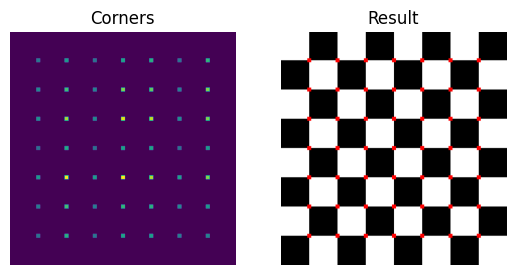

In [24]:
dst = cv.cornerHarris(to_gray(chessboard_img).astype(np.float32),2,3,0.04)
dst[np.where(dst < 0.1 * dst.max())] = 0
dst = cv.dilate(dst,np.ones((3,3)), iterations = 30)
draw_img = chessboard_img.copy()
draw_img[dst != 0] = (0,0,255)
plt.subplot(121); plt.imshow(dst); plt.title("Corners")
plt.axis('off');
plt.subplot(122); plt.imshow(draw_img[...,::-1]); plt.title("Result")
plt.axis('off');

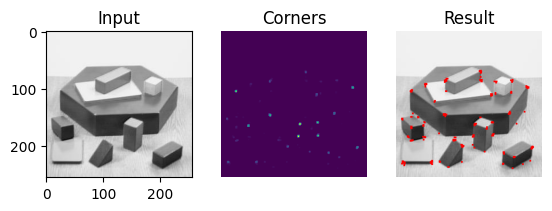

In [65]:
# clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# eqhist = cv.merge([clahe.apply(c) for c in cv.split(blox_img)])
# blured = cv.GaussianBlur(eqhist,(7,7),21)
input_img = blox_img
dst = cv.cornerHarris(to_gray(input_img).astype(np.float32),2,3,0.04)
# Filter dots
dst[np.where(dst < 0.01 * dst.max())] = 0
dst = cv.dilate(dst,np.ones((3,3)), iterations = 1)
draw_img = blox_img.copy()
draw_img[dst != 0] = (0,0,255)
plt.subplot(131); plt.imshow(input_img[...,::-1]); plt.title("Input")
plt.subplot(132); plt.imshow(dst); plt.title("Corners")
plt.axis('off');
plt.subplot(133); plt.imshow(draw_img[...,::-1]); plt.title("Result")
plt.axis('off');

Text(0.5, 1.0, 'Result')

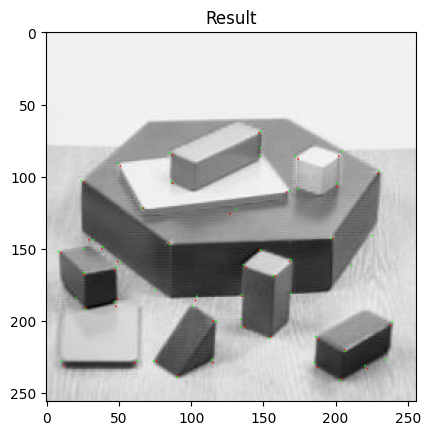

In [73]:
img = blox_img.copy()
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
# find Harris corners
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)
dst = cv.dilate(dst,None)
ret, dst = cv.threshold(dst,0.01*dst.max(),255,0)
dst = np.uint8(dst)
# find centroids
ret, labels, stats, centroids = cv.connectedComponentsWithStats(dst)
# define the criteria to stop and refine the corners
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.001)
corners = cv.cornerSubPix(gray,np.float32(centroids),(5,5),(-1,-1),criteria)
# Now draw them
res = np.hstack((centroids,corners))
res = np.int32(res)
img[res[:,1],res[:,0]]=[0,0,255]
img[res[:,3],res[:,2]] = [0,255,0]

plt.imshow(img[...,::-1]); plt.title("Result")